#### Notebook to analyze the properties of the RedditClusteringP2P dataset

In [1]:
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import Counter

In [2]:
# load datasets
arxiv_data = datasets.load_dataset("mteb/arxiv-clustering-p2p", revision="a122ad7f3f0291bf49cc6f4d32aa80929df69d5d")["test"]
biorxiv_data = datasets.load_dataset("mteb/biorxiv-clustering-p2p", revision="f5dbc242e11dd8e24def4c4268607a49e02946dc")["test"]
medrxiv_data =  datasets.load_dataset("mteb/medrxiv-clustering-p2p", revision="e7a26af6f3ae46b30dde8737f02c07b1505bcc73")["test"]
reddit_data = datasets.load_dataset("mteb/reddit-clustering-p2p", revision="385e3cb46b4cfa89021f56c4380204149d0efe33")["test"]
stackexchange_data = datasets.load_dataset("mteb/stackexchange-clustering-p2p", revision="815ca46b2622cec33ccafc3735d572c266efdb44")["test"]

### Reddit data

In [3]:
with open("dict_label_to_color_reddit.pkl", "rb") as d:
    color_dict = pickle.load(d)


Text(20, 77908, '# labels: 450 \n# texts: 459399')

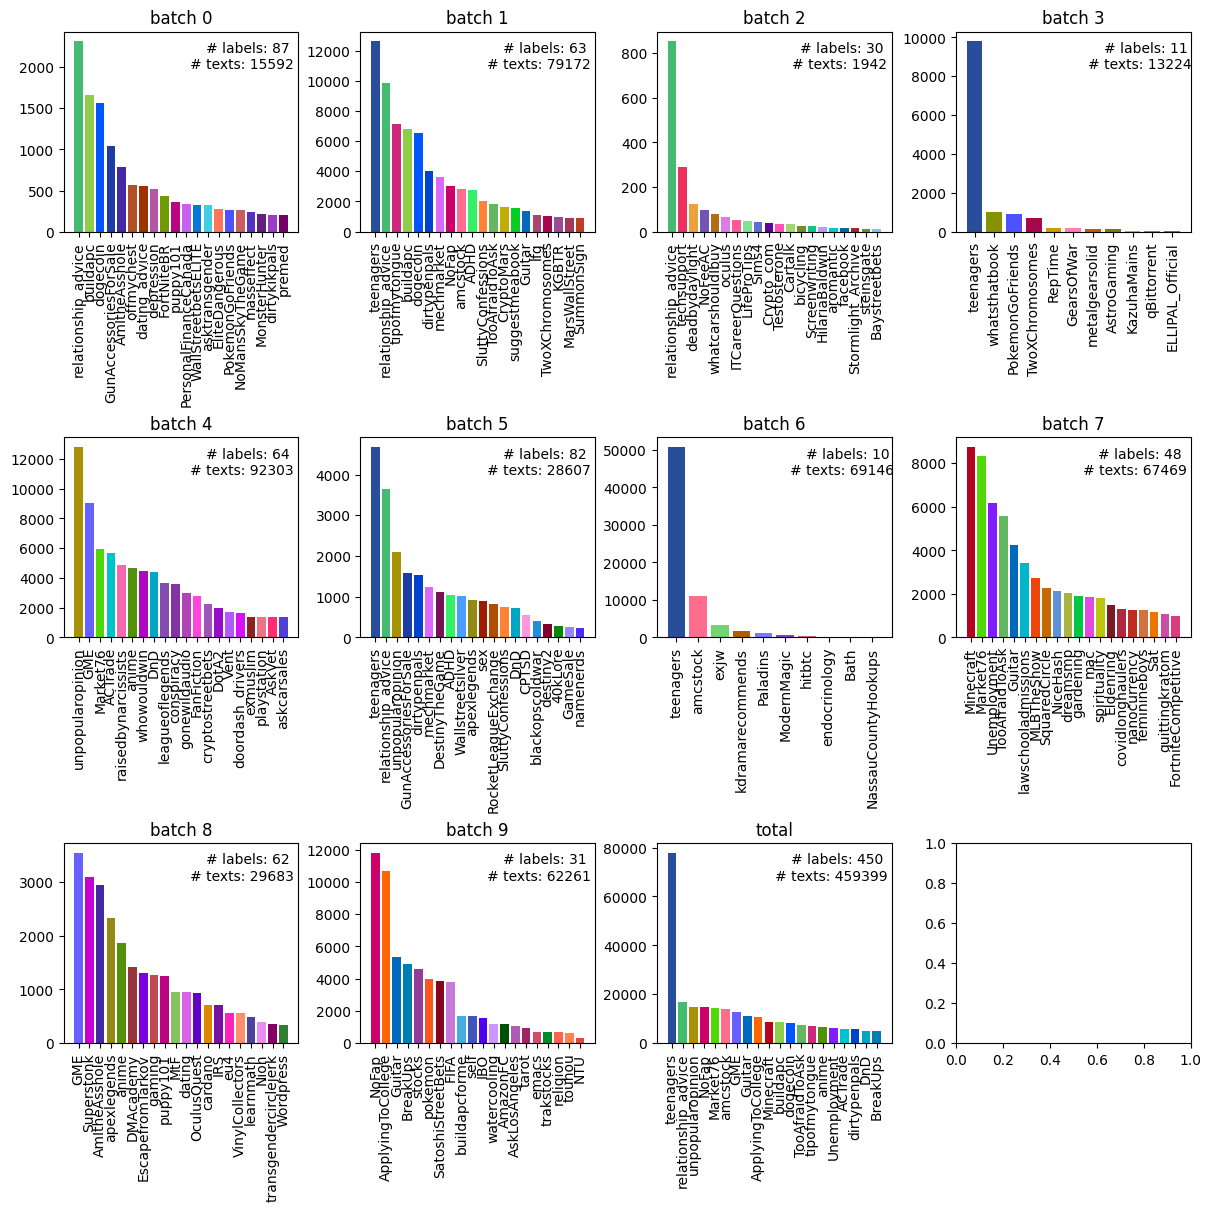

In [4]:
ncols = 4
nrows = 3
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12,12), layout="constrained")

row = 0
col = 0

for i, split in enumerate(reddit_data):
    label_counts = Counter(split["labels"])
    n_labels = len(label_counts)
    n_texts = len(split["labels"])
    topk = label_counts.most_common(20)
    labels = [label for label, _ in topk]
    counts = [count for _, count in topk]
    colors = [color_dict[label] for label in labels]

    ax = axs[row, col]
    ax.bar(labels, counts, color=colors)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(label=f"batch {i}")
    ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

    col += 1
    if col % ncols == 0:
        col = 0
        row += 1

# plot overall label dist
all_labels = []
for split in reddit_data:
    all_labels += split["labels"]

label_counts = Counter(all_labels)
n_labels = len(label_counts)
n_texts = len(all_labels)
topk = label_counts.most_common(20)
labels = [label for label, _ in topk]
counts = [count for _, count in topk]
colors = [color_dict[label] for label in labels]

ax = axs[row, col]
ax.bar(labels, counts, color=colors)
ax.tick_params(axis='x', rotation=90)
ax.set_title(label=f"total")
ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")


#### Arxiv data

In [23]:
arxiv_all_labels = [x for split in arxiv_data for x in split["labels"]]
unique_labels = list(set(arxiv_all_labels))


In [9]:
colors = sns.color_palette("hls", len(unique_labels))
color_dict = dict(zip(unique_labels, colors))

Text(20, 61342, '# labels: 180 \n# texts: 732723')

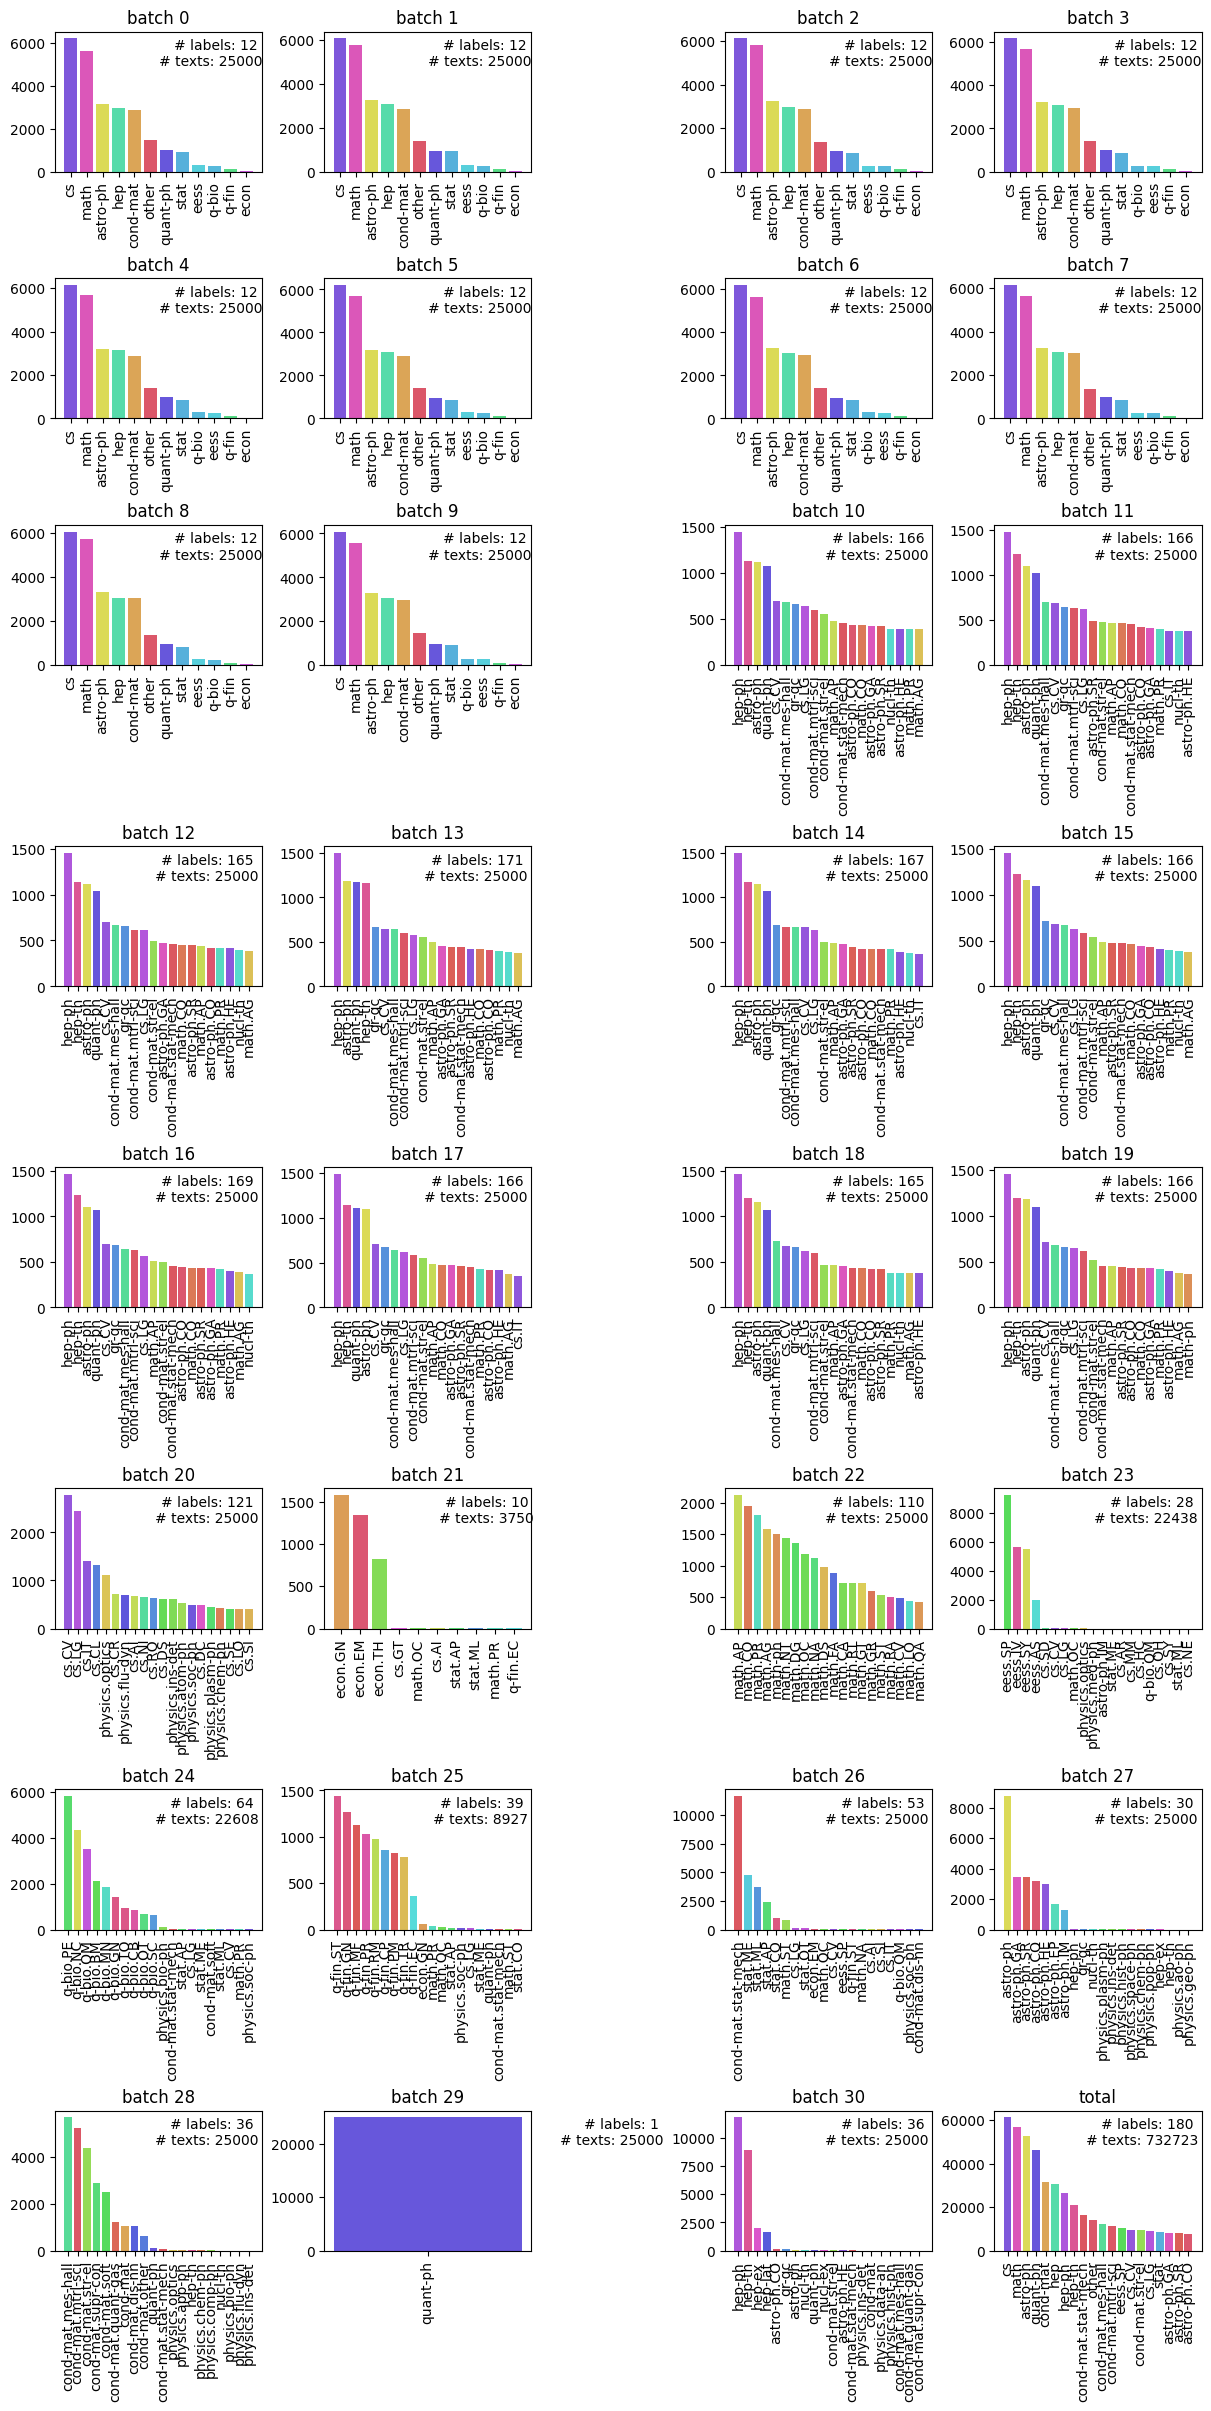

In [24]:
ncols = 4
nrows = 8
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12,24), layout="constrained")

row = 0
col = 0

for i, split in enumerate(arxiv_data):
    label_counts = Counter(split["labels"])
    n_labels = len(label_counts)
    n_texts = len(split["labels"])
    topk = label_counts.most_common(20)
    labels = [label for label, _ in topk]
    counts = [count for _, count in topk]
    colors = [color_dict[label] for label in labels]

    ax = axs[row, col]
    ax.bar(labels, counts, color=colors)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(label=f"batch {i}")
    ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

    col += 1
    if col % ncols == 0:
        col = 0
        row += 1

# plot overall label dist
label_counts = Counter(arxiv_all_labels)
n_labels = len(label_counts)
n_texts = len(arxiv_all_labels)
topk = label_counts.most_common(20)
labels = [label for label, _ in topk]
counts = [count for _, count in topk]
colors = [color_dict[label] for label in labels]

ax = axs[row, col]
ax.bar(labels, counts, color=colors)
ax.tick_params(axis='x', rotation=90)
ax.set_title(label=f"total")
ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

In [26]:
#### Biorxiv data
biorxiv_all_labels = [split["labels"] for split in biorxiv_data]
unique_labels = list(set(biorxiv_all_labels))


In [27]:
colors = sns.color_palette("hls", len(unique_labels))
color_dict = dict(zip(unique_labels, colors))

Text(20, 9821, '# labels: 26 \n# texts: 53787')

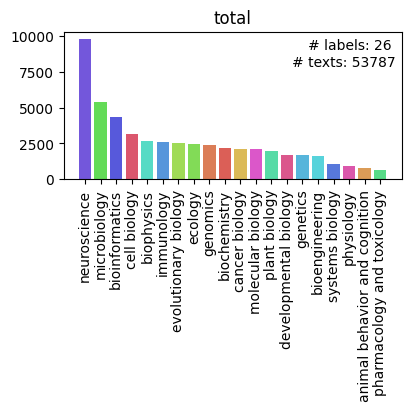

In [28]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4,4), layout="constrained")

label_counts = Counter(biorxiv_all_labels)
n_labels = len(label_counts)
n_texts = len(biorxiv_all_labels)
topk = label_counts.most_common(20)
labels = [label for label, _ in topk]
counts = [count for _, count in topk]
colors = [color_dict[label] for label in labels]

ax.bar(labels, counts, color=colors)
ax.tick_params(axis='x', rotation=90)
ax.set_title(label=f"total")
ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

#### Medrxiv data

In [29]:
medrxiv_all_labels = [x for split in medrxiv_data for x in split["labels"]]
unique_labels = list(set(medrxiv_all_labels))

In [30]:
colors = sns.color_palette("hls", len(unique_labels))
color_dict = dict(zip(unique_labels, colors))

Text(20, 8830, '# labels: 51 \n# texts: 37500')

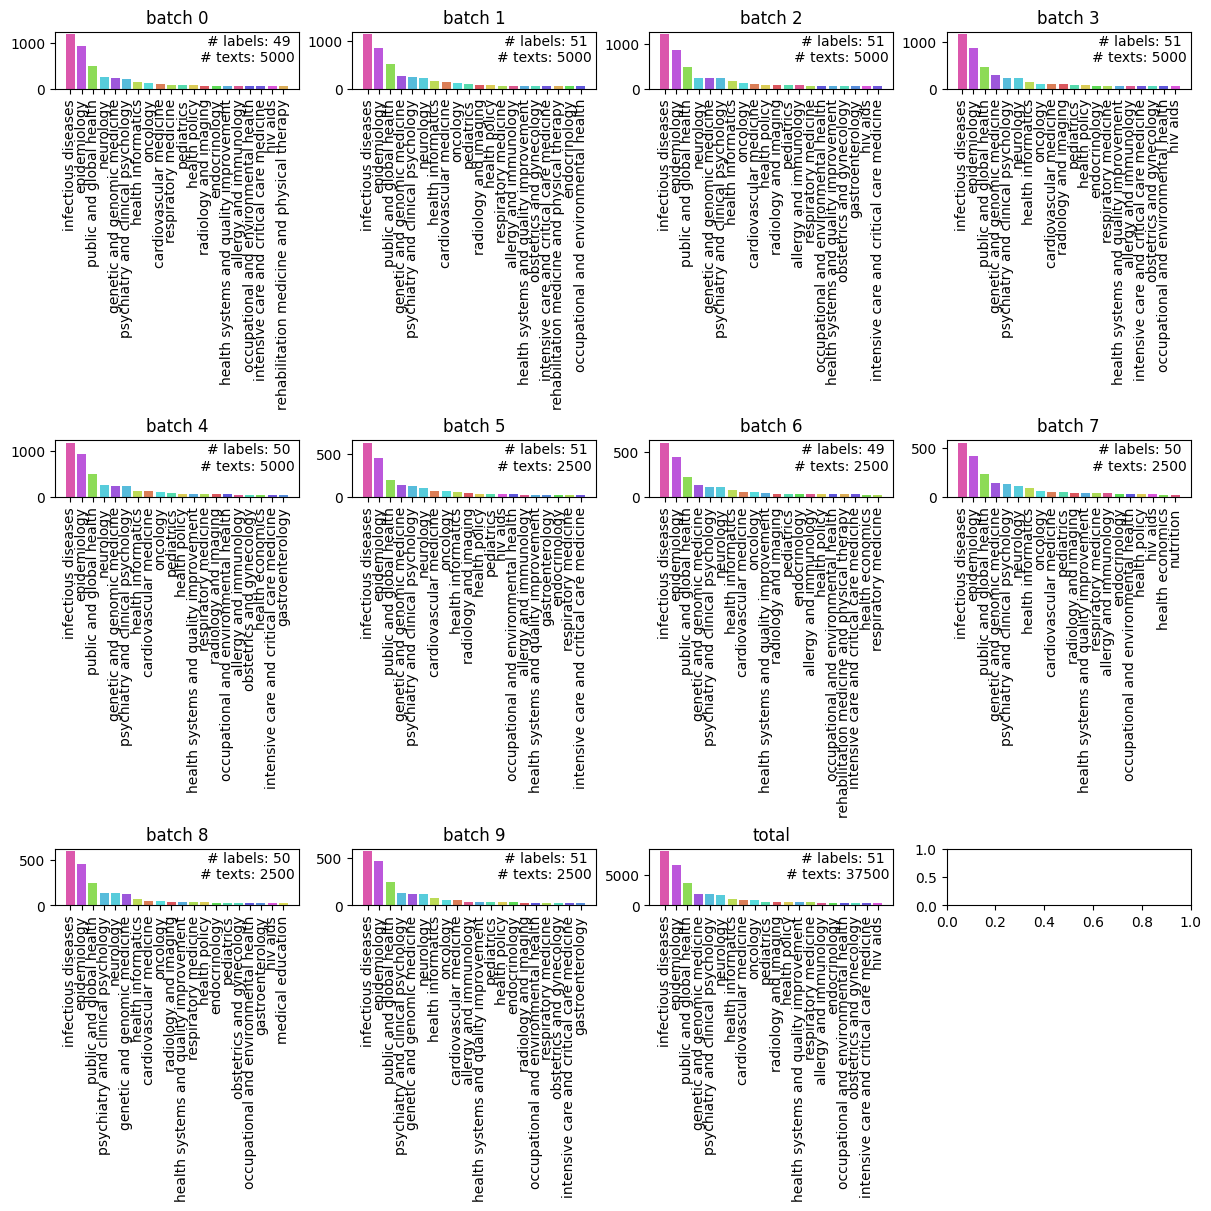

In [31]:
ncols = 4
nrows = 3
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12,12), layout="constrained")

row = 0
col = 0

for i, split in enumerate(medrxiv_data):
    label_counts = Counter(split["labels"])
    n_labels = len(label_counts)
    n_texts = len(split["labels"])
    topk = label_counts.most_common(20)
    labels = [label for label, _ in topk]
    counts = [count for _, count in topk]
    colors = [color_dict[label] for label in labels]

    ax = axs[row, col]
    ax.bar(labels, counts, color=colors)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(label=f"batch {i}")
    ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

    col += 1
    if col % ncols == 0:
        col = 0
        row += 1

# plot overall label dist
label_counts = Counter(medrxiv_all_labels)
n_labels = len(label_counts)
n_texts = len(medrxiv_all_labels)
topk = label_counts.most_common(20)
labels = [label for label, _ in topk]
counts = [count for _, count in topk]
colors = [color_dict[label] for label in labels]

ax = axs[row, col]
ax.bar(labels, counts, color=colors)
ax.tick_params(axis='x', rotation=90)
ax.set_title(label=f"total")
ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

#### Stackexchange data

In [33]:
se_all_labels = [x for split in stackexchange_data for x in split["labels"]]
unique_labels = list(set(se_all_labels))

In [34]:
colors = sns.color_palette("hls", len(unique_labels))
color_dict = dict(zip(unique_labels, colors))

Text(20, 18476, '# labels: 610 \n# texts: 75000')

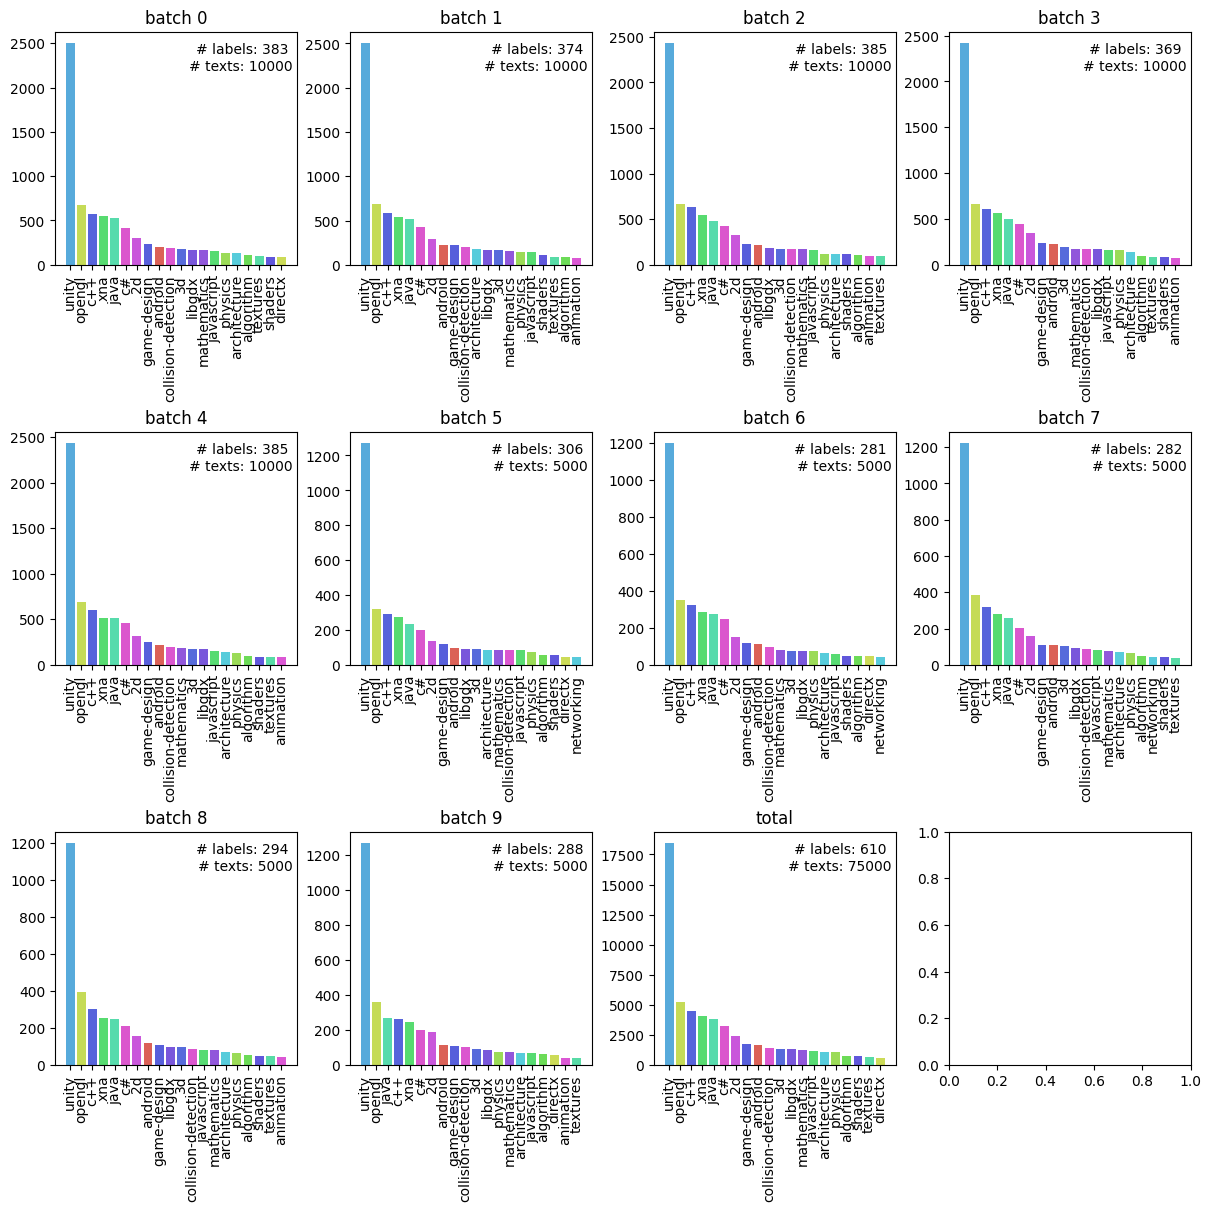

In [35]:
ncols = 4
nrows = 3
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12,12), layout="constrained")

row = 0
col = 0

for i, split in enumerate(stackexchange_data):
    label_counts = Counter(split["labels"])
    n_labels = len(label_counts)
    n_texts = len(split["labels"])
    topk = label_counts.most_common(20)
    labels = [label for label, _ in topk]
    counts = [count for _, count in topk]
    colors = [color_dict[label] for label in labels]

    ax = axs[row, col]
    ax.bar(labels, counts, color=colors)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(label=f"batch {i}")
    ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")

    col += 1
    if col % ncols == 0:
        col = 0
        row += 1

# plot overall label dist
label_counts = Counter(se_all_labels)
n_labels = len(label_counts)
n_texts = len(se_all_labels)
topk = label_counts.most_common(20)
labels = [label for label, _ in topk]
counts = [count for _, count in topk]
colors = [color_dict[label] for label in labels]

ax = axs[row, col]
ax.bar(labels, counts, color=colors)
ax.tick_params(axis='x', rotation=90)
ax.set_title(label=f"total")
ax.text(len(topk),counts[0], f"# labels: {n_labels} \n# texts: {n_texts}",
            horizontalalignment = "right", verticalalignment = "top")